# Welcome to seaborn

## Importing Libraries and Why Seaborn?

- provides a layer of abstraction hence simpler to use
- better aesthetics
- more graphs included

### Seaborn Roadmap

Types of Functions

- Figure Level
- Axis Level

Main Classification

- Relational Plot
- Distribution Plot
- Categorical Plot
- Regression Plot
- Matrix Plot
- Multiplots

https://seaborn.pydata.org/api.html

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px #used here only for inbuilt datasets.
import scipy.cluster.hierarchy as sp #required to generate clustermaps.

## Importing built-in datasets

In [3]:
tips = sns.load_dataset('tips')
tips.head() 
iris = px.data.iris()
#guess how pandas .head() function worked without importing the library, cause under the hood it was imported by seaborn. 

## 1. Relational Plot

- to see the statistical relation between 2 or more variables.
- Bivariate Analysis

Plots under this section

- scatterplot
- lineplot

### Scatterplot

<Axes: xlabel='total_bill', ylabel='tip'>

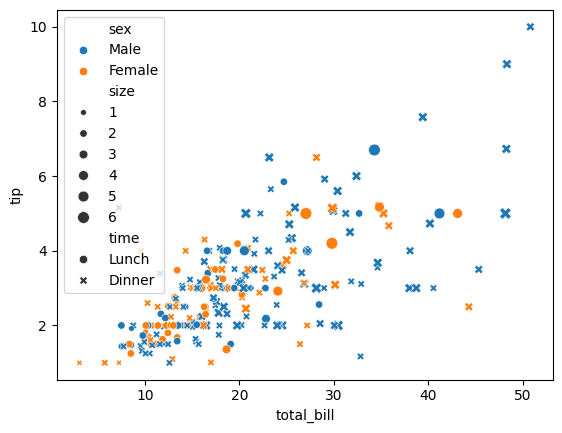

In [4]:
# Scatterplot - Axes level function

sns.scatterplot(data=tips,x='total_bill',y='tip',hue='sex',style='time',size='size')
# auto generates the legend.
# we can add additional details in the scatterplot by adding more categorical variables.

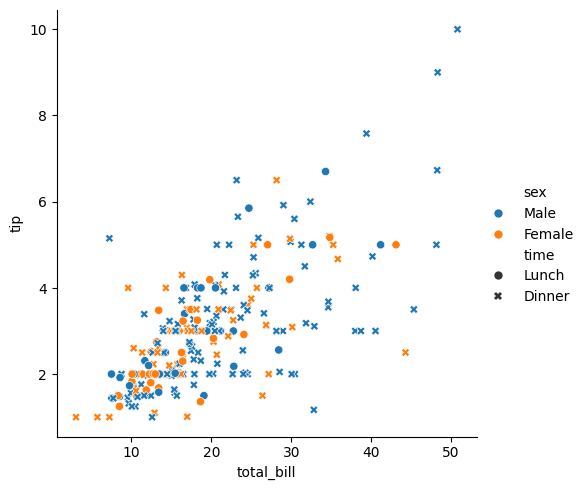

In [5]:
#Relplot -> a figure level function -> generally outputs square shaped image.

sns.relplot(data=tips, x='total_bill',y='tip',kind='scatter',hue='sex',style='time')
plt.show() # this removes unnecessary calculation details.

### Lineplot

Lineplot is just a connected scatterplot.
It is useful when we have to show continuity in our data.

- Specially useful to represent time variables.

In [6]:
# importing inbuilt dataset from plotly
gap = px.data.gapminder()
gap.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [7]:
temp_df = gap[gap['country'] == 'India']
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
696,India,Asia,1952,37.373,372000000,546.565749,IND,356
697,India,Asia,1957,40.249,409000000,590.061996,IND,356
698,India,Asia,1962,43.605,454000000,658.347151,IND,356
699,India,Asia,1967,47.193,506000000,700.770611,IND,356
700,India,Asia,1972,50.651,567000000,724.032527,IND,356


<Axes: xlabel='year', ylabel='lifeExp'>

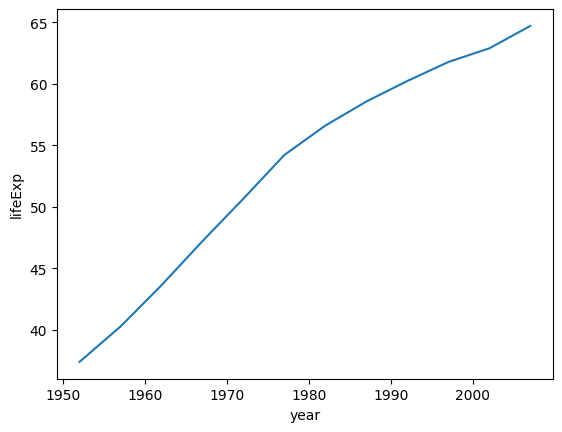

In [8]:
# axes level function

sns.lineplot(data=temp_df,x='year',y='lifeExp')

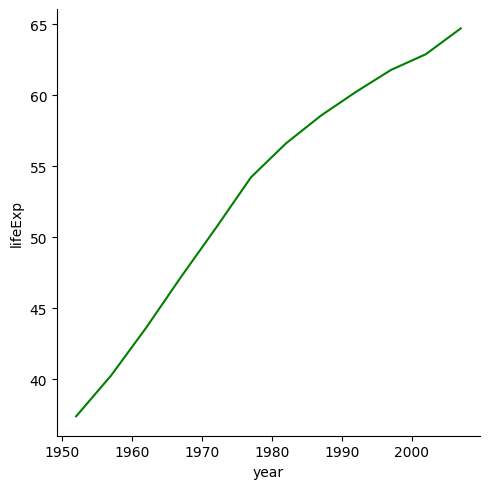

In [9]:
# plotting using figure level function - relplot

sns.relplot(data=temp_df,x='year',y='lifeExp',kind='line',color='green')

In [10]:
# hue / style

temp_df = gap[gap['country'].isin(['India','Brazil','Germany'])]

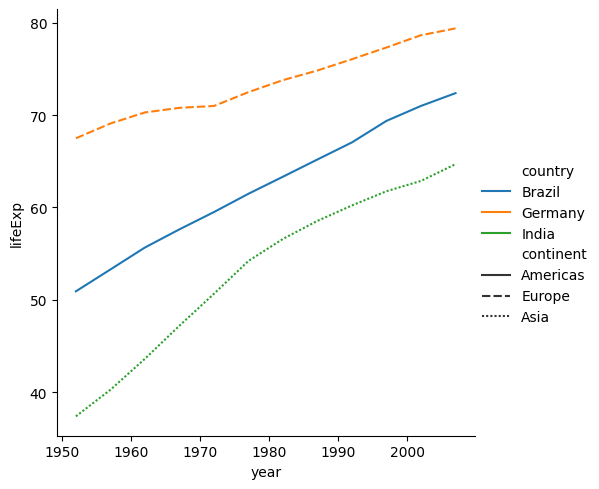

In [11]:
sns.relplot(kind='line', data=temp_df, x='year',y='lifeExp',hue='country',style='continent')

<Axes: xlabel='year', ylabel='lifeExp'>

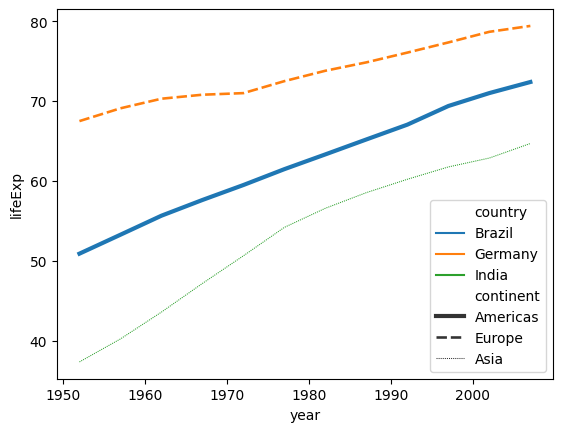

In [12]:
sns.lineplot(data=temp_df, x='year',y='lifeExp',hue='country',size='continent',style='continent')

### Facet Plot

A facet plot (also known as a small multiple or trellis plot) is a data visualization technique that splits a single chart into a grid of multiple subplots. Each subplot displays a specific subset of the data based on a categorical variable, making it easy to compare trends across different groups at a glance.

> ** Only works with figure level functions - means relplot() only, not sns.scatterplot()

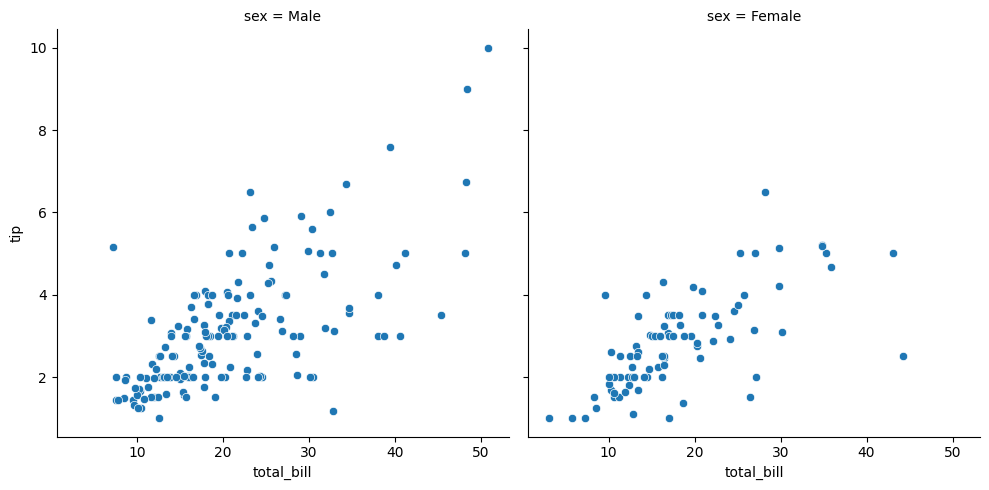

In [13]:
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='sex')

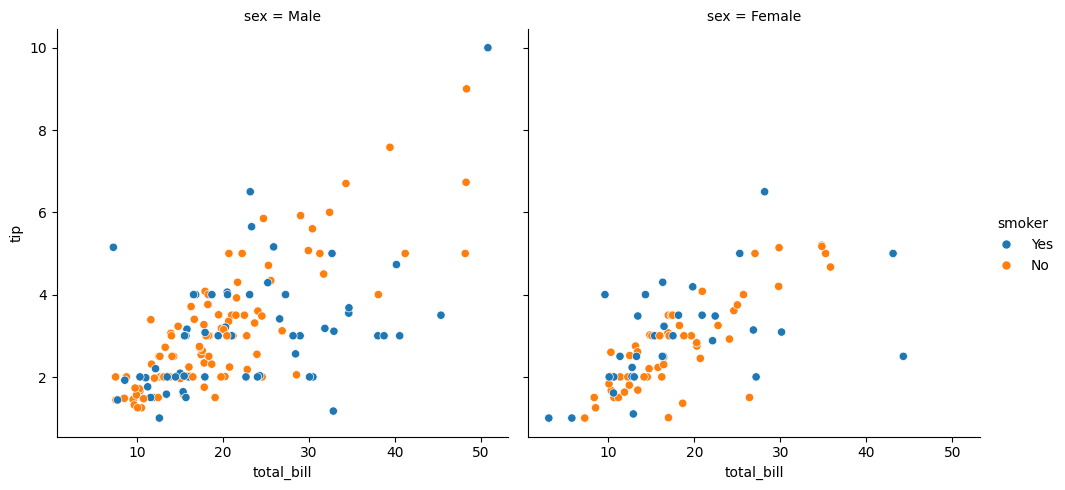

In [14]:
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',hue='smoker',col='sex')
# sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',row='smoker',col='sex') #this will give 4 subplots


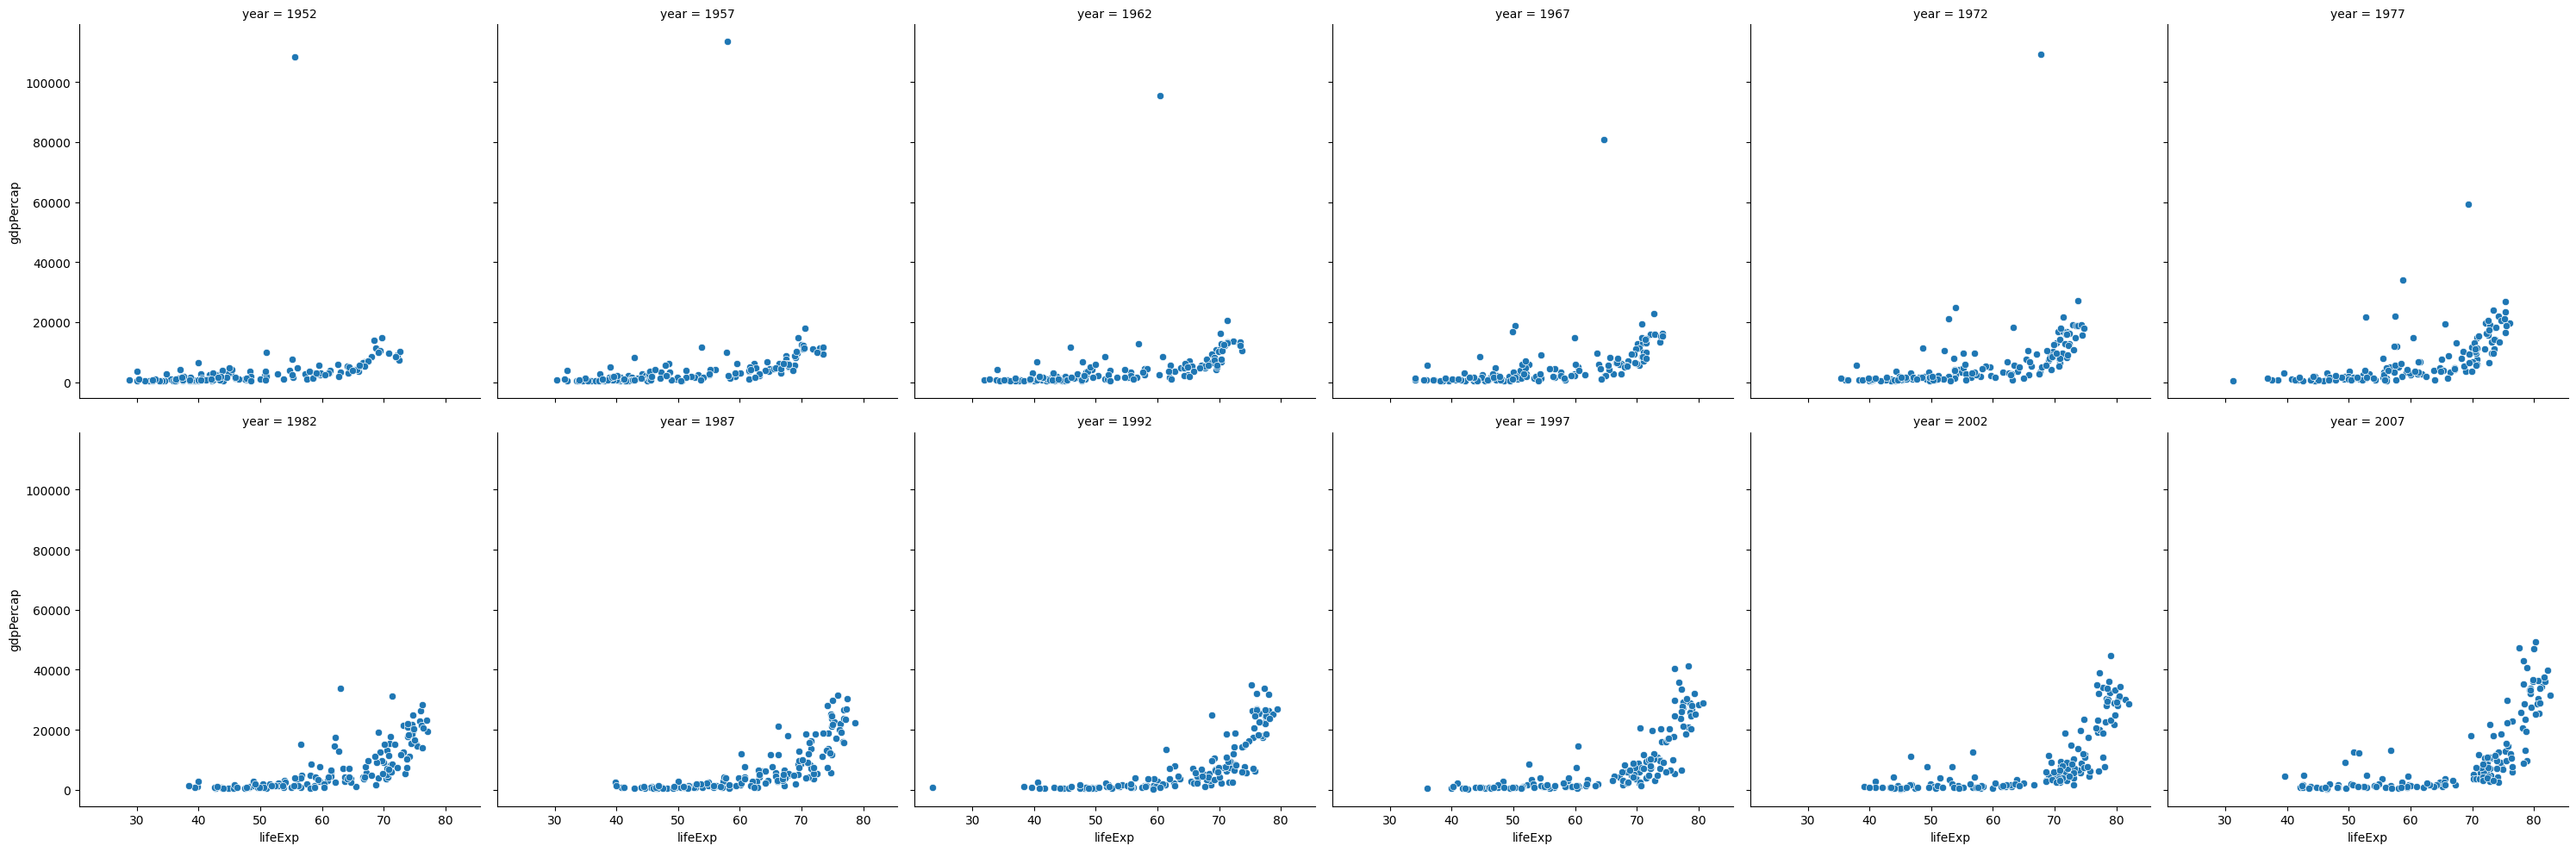

In [15]:
# col wrap - if there are a lot of subplots in 1 column then wrap it. 

sns.relplot(data=gap,x='lifeExp',y='gdpPercap', kind='scatter',col='year',col_wrap=6)

## 2. Distribution Plots

- used for univariate analysis
- used to find out the statistical distribution
- Range of the observation
- Central Tendency
- Is the data bimodal?
- Are there outliers?

Plots under distribution plot
- histplot
- kdeplot
- rugplot

**Axes level function** - histplot(), kdeplot(), rugplot()

**Figure level function** - displot()

### Histplot  (Histogram)

<Axes: xlabel='total_bill', ylabel='Count'>

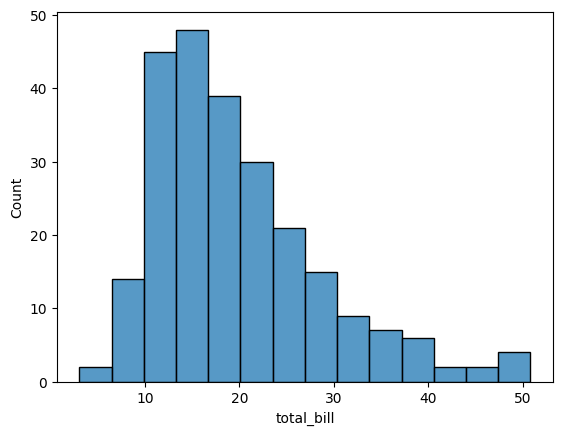

In [16]:
sns.histplot(data=tips,x='total_bill')

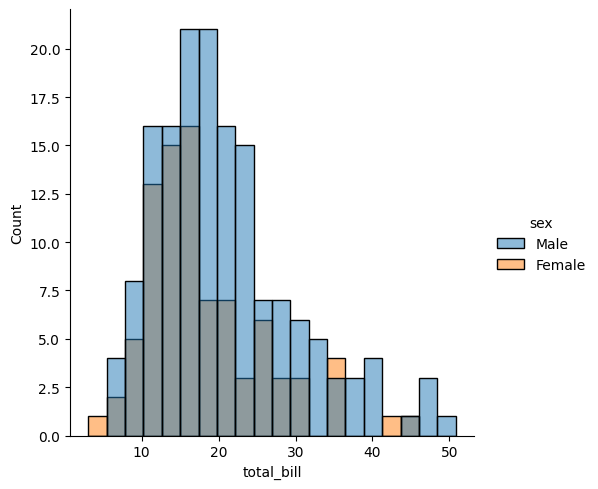

In [17]:
sns.displot(kind='hist',data=tips,x='total_bill',bins=20,hue='sex')

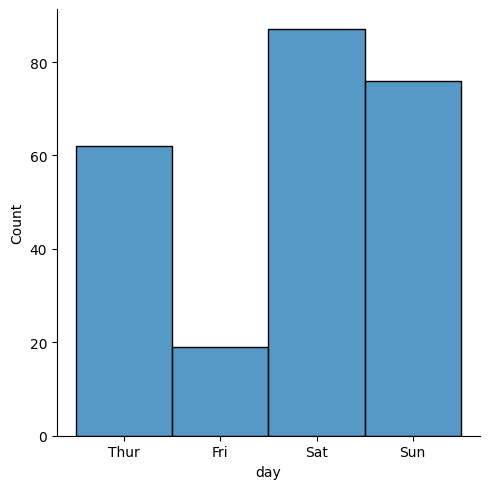

In [18]:
# plotting on a categorical column - it's more like count plot

sns.displot(data=tips,x='day',kind='hist')

In [19]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


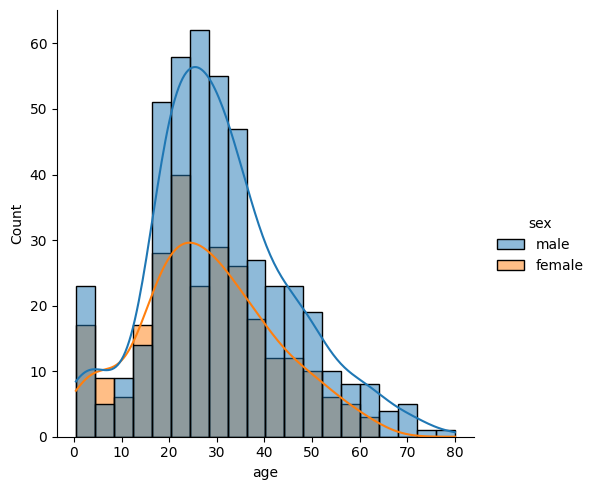

In [20]:
sns.displot(titanic,x='age',kind='hist',hue='sex',kde=True)

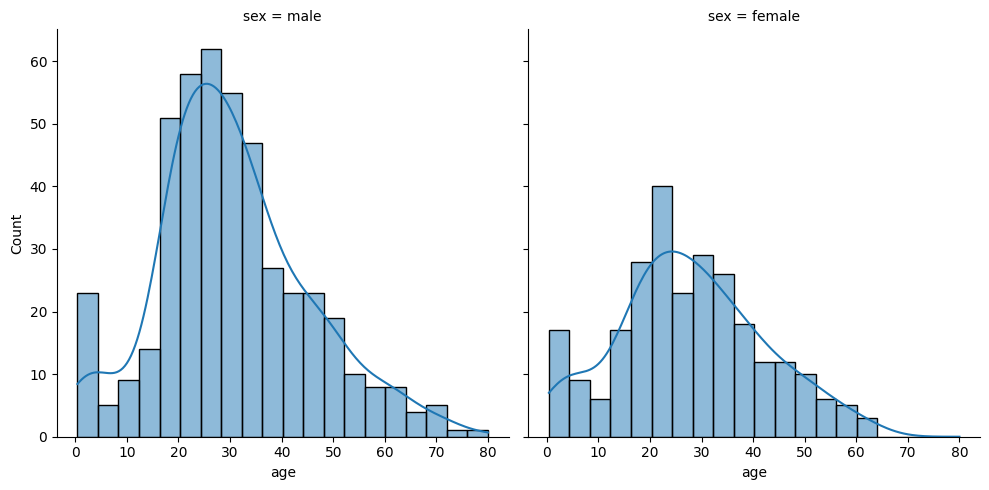

In [21]:
# facet plotting
sns.displot(titanic,x='age',kind='hist',col='sex',kde=True)

### Kdeplot

Rather than using discrete bins, a kDE plot smooths the observations with a gaussian kernel, producing a contiuous density estimates.

<Axes: xlabel='total_bill', ylabel='Density'>

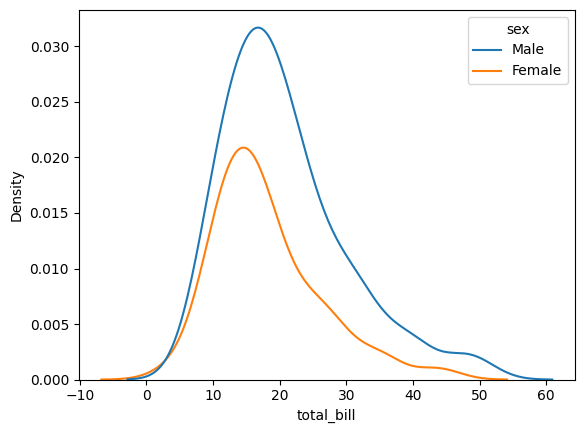

In [22]:
sns.kdeplot(data=tips,x='total_bill',hue='sex')

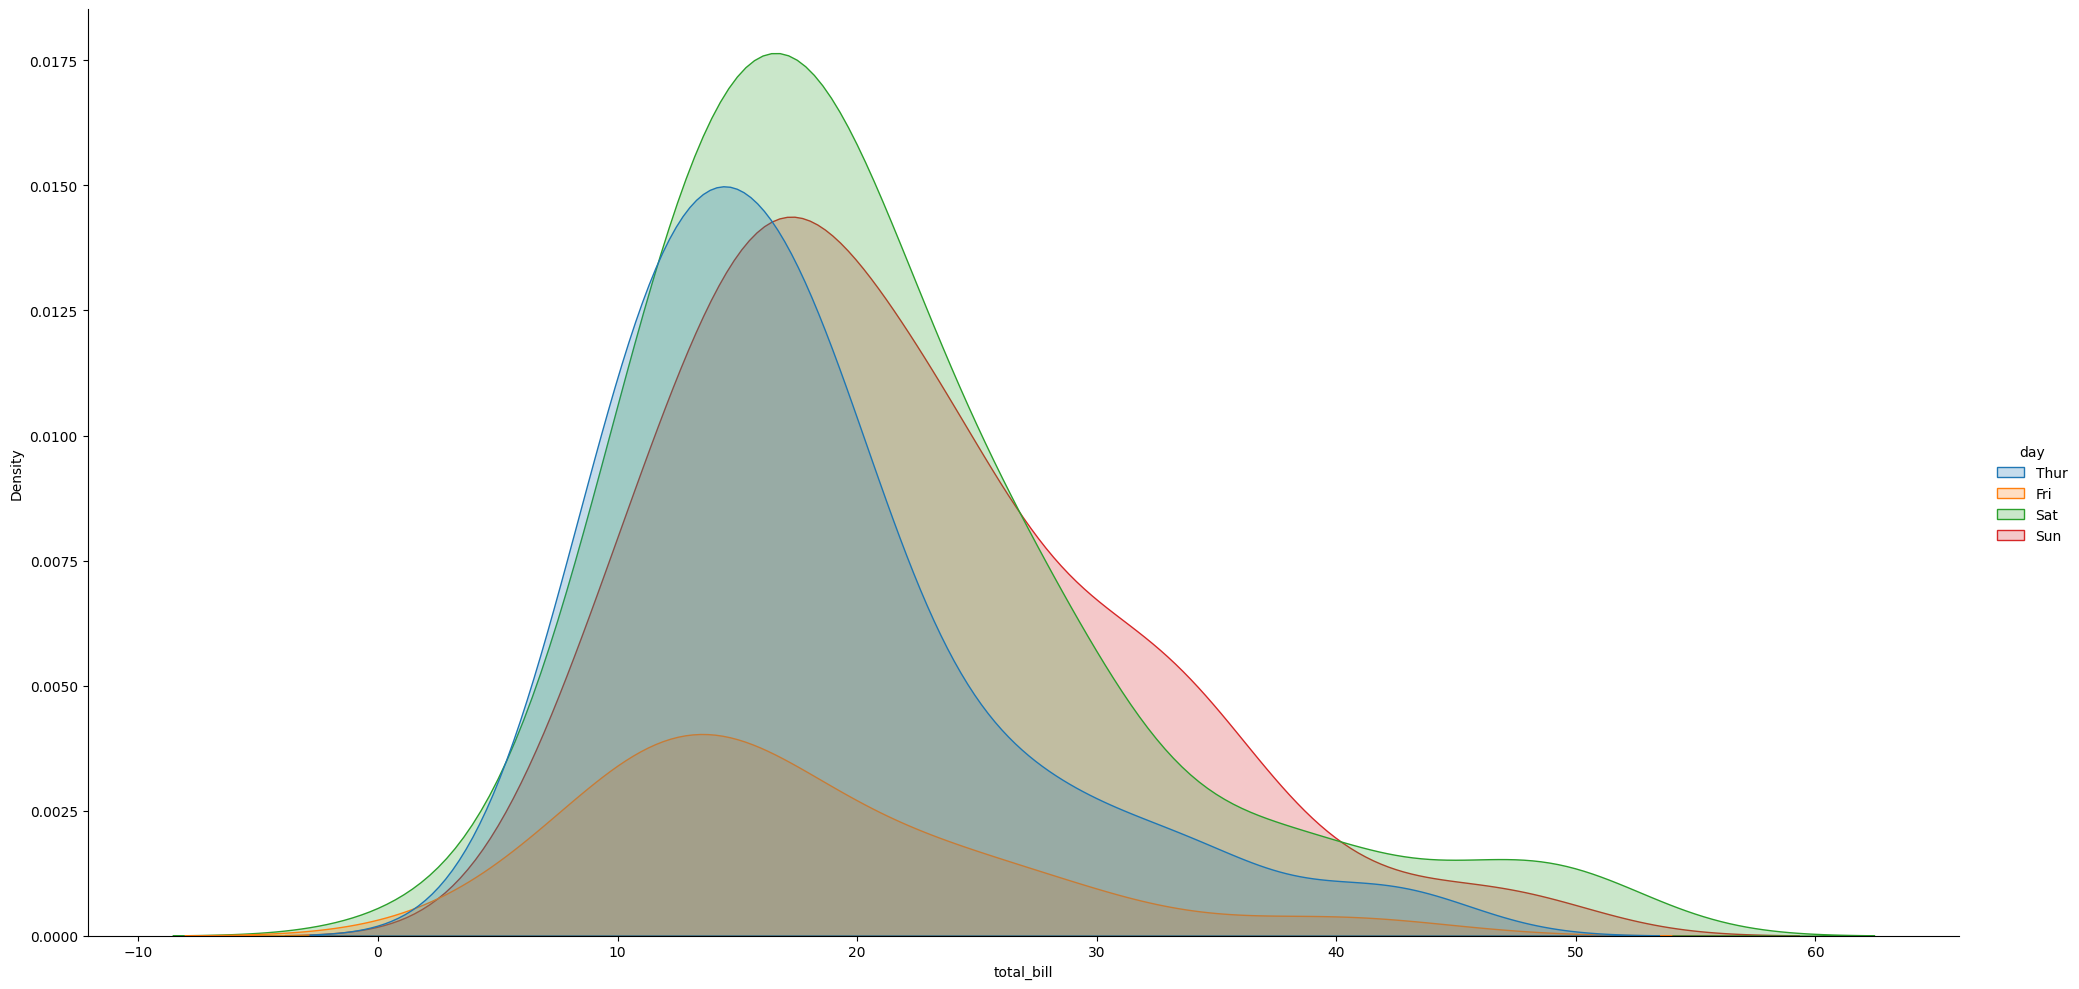

In [23]:
sns.displot(data=tips,x='total_bill',kind='kde',hue='day',fill=True,height=10,aspect=2)
# we cannot use matplotlib to change the size of figure level functions
# so we use height to change the size, and aspect ratio for width.

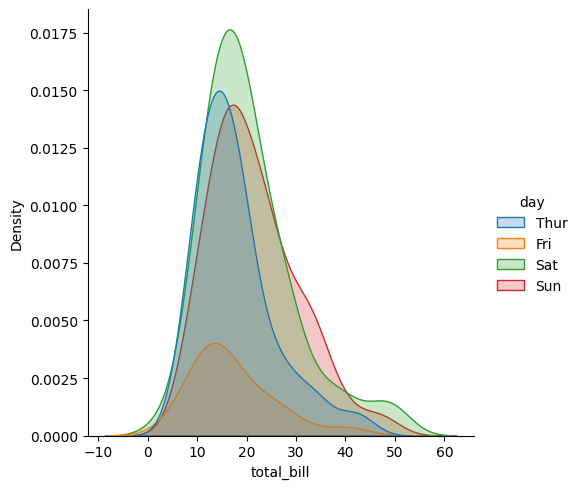

In [24]:
sns.displot(data=tips,x='total_bill',kind='kde',hue='day',fill=True)

### Rugplot

- Plot marginal distribution by drawing ticks along the x and y axes.
- This function is intended to complement other plots by showing the location of individual observations in an unobstrusive way.

A rug plot is a simple and compact data visualization that displays the exact distribution of a single quantitative variable along an axis. Instead of binning or grouping data (like a histogram), it represents every individual data point as a single perpendicular tick mark or line.

**Usecase**
- Outlier Detection
- As an Underlay
- Shows density

<Axes: xlabel='total_bill', ylabel='Density'>

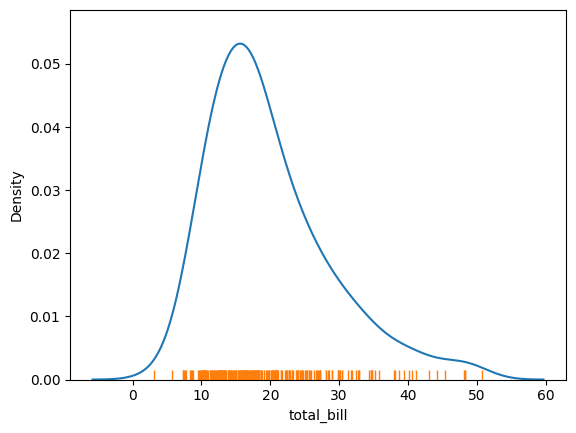

In [25]:
sns.kdeplot(data=tips,x='total_bill')
sns.rugplot(data=tips,x='total_bill')

### Bivariate Histogram

- A bivariate histogram bins the data within rectangles that tile the plot and then shows the count of observation within each rectangle with the fill color

<Axes: xlabel='total_bill', ylabel='tip'>

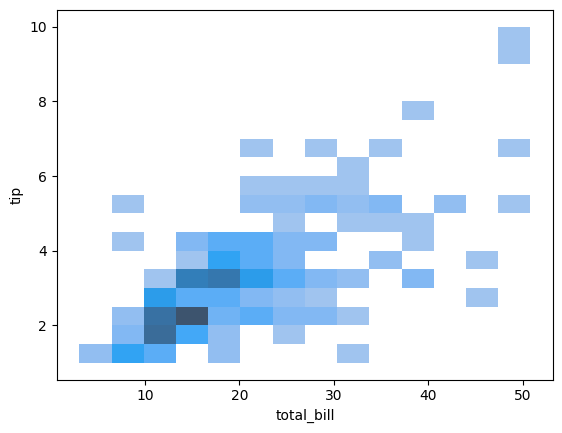

In [26]:
sns.histplot(data=tips,x='total_bill',y='tip')
# same can be done with displot.
#here darker color means more values lies there

### Bivariate Kdeplot

a bivariate KDE plot smoothes the (x,y) observations with a 2d gaussian function

<Axes: xlabel='total_bill', ylabel='tip'>

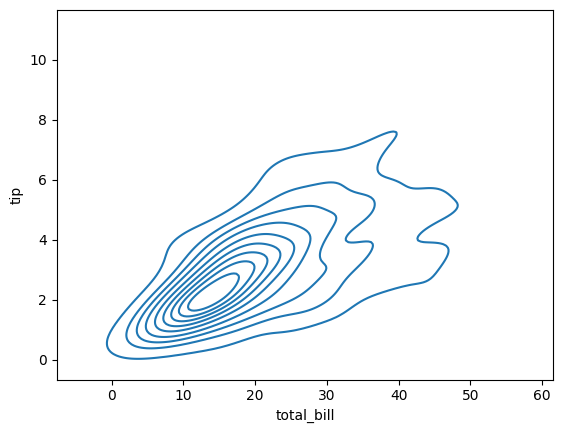

In [27]:
sns.kdeplot(data=tips,x='total_bill',y='tip')

## 3. Categorical Plot

**Categorical Scatter Plot**

- Stripplot
- Swarmplot

**Categorical Distribution Plot**

- Boxplot
- Violinplot

**Categorical Estimate Plot** For central tenedency

- Barplot
- Pointplot
- Countplot

***Figure level function - catplot()***

### Categorical Scatter Plot

#### Stripplot

<Axes: xlabel='day', ylabel='total_bill'>

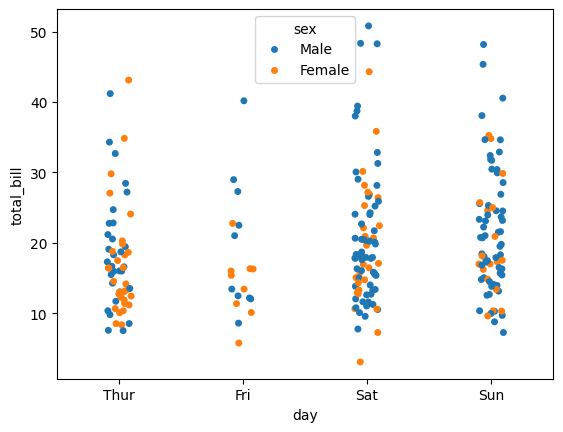

In [28]:
sns.stripplot(data=tips,x='day',y='total_bill',hue='sex')

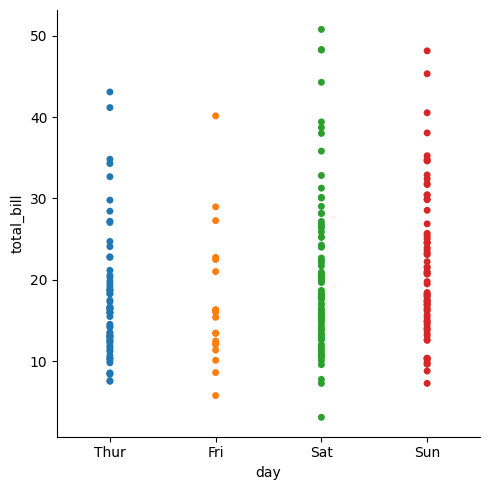

In [29]:
# jitter = False, but plotting using figure level function catplot

sns.catplot(kind='strip',data=tips,x='day',y='total_bill',hue='day',jitter=False)
# technically it should be in a straight line, but some noise(jitter) 
# is added to increase the visibility.
# we can assign a jitter value to change the noise. jitter=0.15

#### Swarmplot

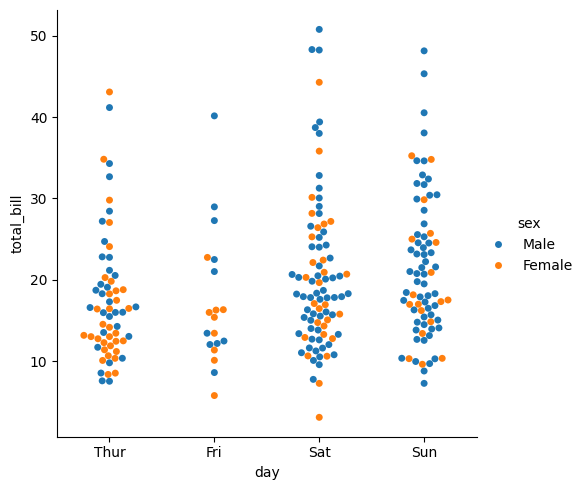

In [30]:
sns.catplot(kind='swarm',data=tips, x= 'day',y='total_bill',hue='sex') # figure level
# sns.swarmplot(data=tips, x= 'day',y='total_bill',hue='sex') #axes level

### Categorical Distribution Plot

#### Boxplot 

(<Axes: ylabel='total_bill'>,)

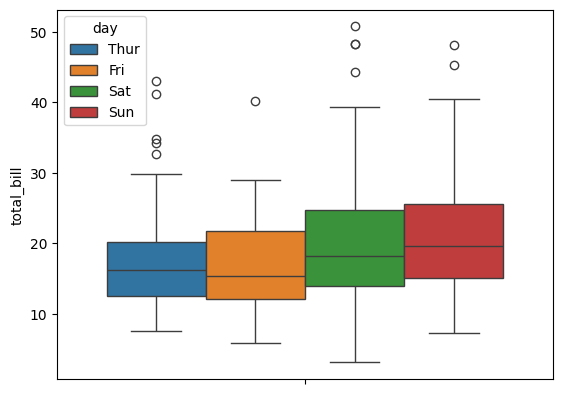

In [31]:
sns.boxplot(data=tips,y='total_bill',hue='day'), #new version: instead of x we can give hue.
# sns.catplot(kind='box',data=tips,y='total_bill',hue='sex',legend=False)

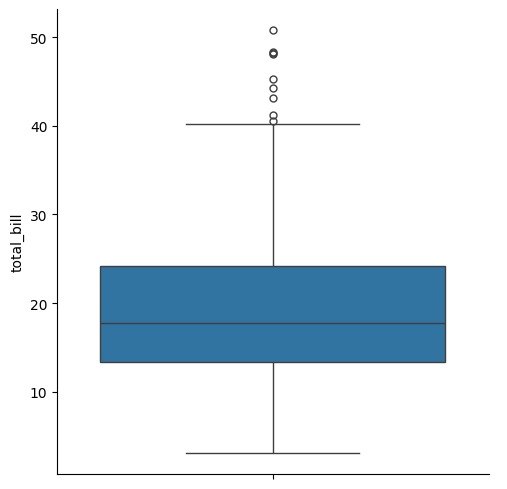

In [32]:
# Boxplot on a single numerical column to get 5 number summary.

sns.catplot(kind='box',data=tips,y='total_bill')

#### Violinplot = [Boxplot + KDEplot]

<Axes: xlabel='day', ylabel='total_bill'>

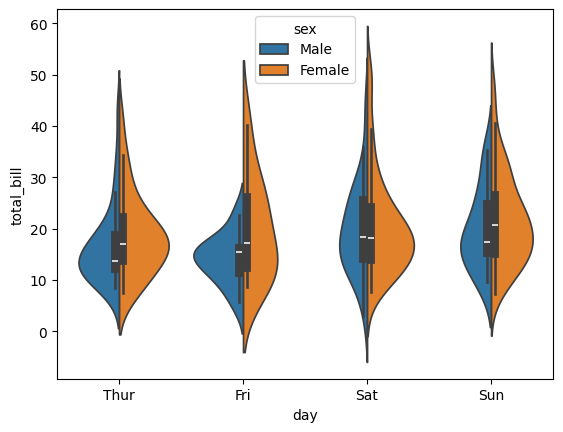

In [33]:
sns.violinplot(data=tips,x='day',y='total_bill',hue='sex',split=True)

# sns.catplot(kind='violin',data=tips,y='total_bill',hue='day',legend=False)

### Categorical Estimate Plot

#### Barplot

Used to show an aggregated value among a categorical and numerical variable.

<Axes: xlabel='sex', ylabel='total_bill'>

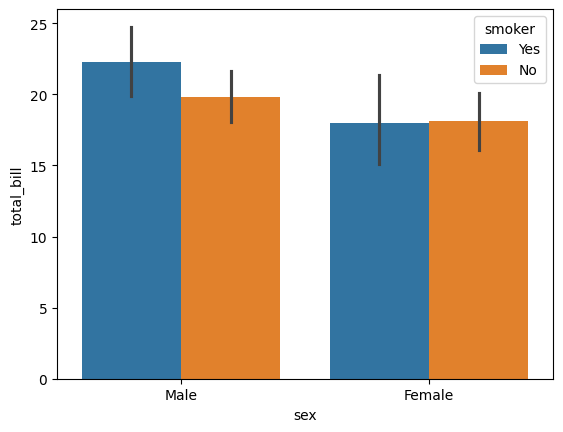

In [34]:
sns.barplot(data=tips,x='sex',y='total_bill',hue='smoker',estimator=np.mean)

#default estimator is mean.

# Those lines on the top are called error bar.
# When there are multiple observation in each category, 
# it also uses bootstraping to compute a confidence interval 
# around the estimate, which is plotted using error bars.

#### Pointplot

<Axes: xlabel='sex', ylabel='total_bill'>

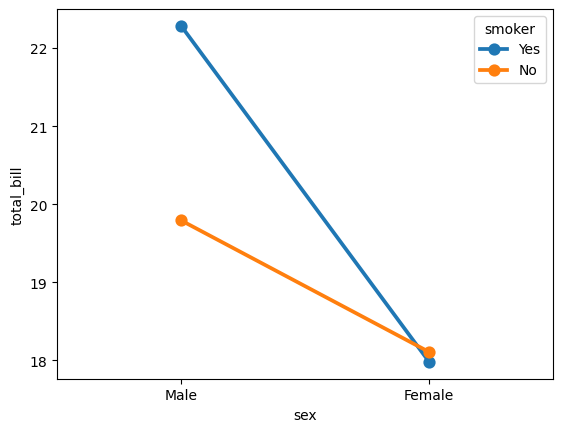

In [35]:
sns.pointplot(data=tips,x='sex',y='total_bill',hue='smoker',errorbar=None)

#Use errorbar=None, to see no errorbars.

#### Countplot

<Axes: xlabel='sex', ylabel='count'>

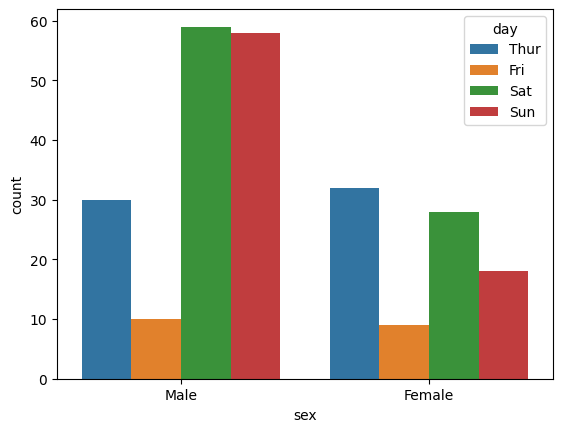

In [36]:
# basically a graph of pandas value count function.
sns.countplot(data=tips,x='sex',hue='day')

#### Facetplots using catplot

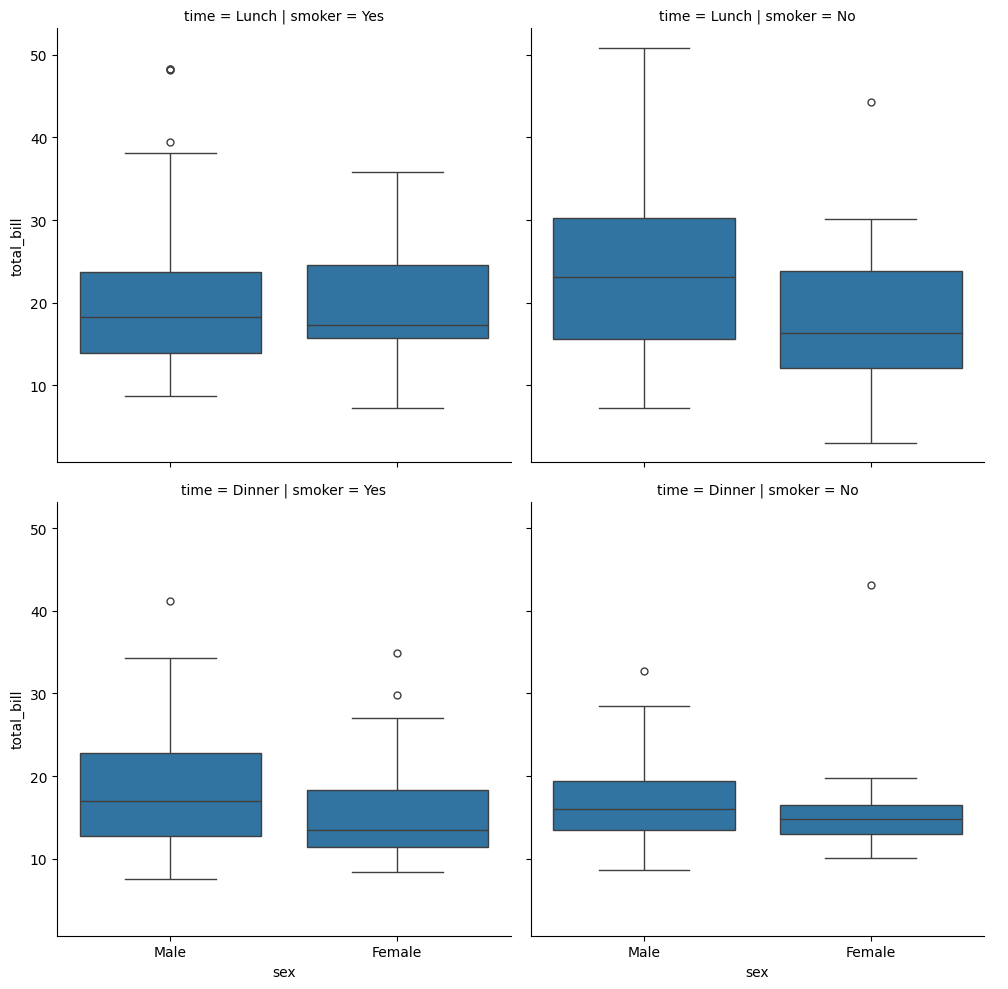

In [37]:
sns.catplot(data=tips,x='sex',y='total_bill',col='smoker',kind='box',row='time')

## 4. Matrix Plot

- Heatmap
- Clustermap

### Heatmap

- Plot rectangular data as a color-encoded matrix

In [38]:
# Lets work on the gap dataset, but first lets 
# convert he long data to wide data by pivoting it.

temp_df = gap.pivot(index='country',columns='year',values='lifeExp')
temp_df.head()

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
country,,,,,,,,,,,,
Afghanistan,28.801,30.332,31.997,34.020,36.088,38.438,39.854,40.822,41.674,41.763,42.129,43.828
Albania,55.230,59.280,64.820,66.220,67.690,68.930,70.420,72.000,71.581,72.950,75.651,76.423
Algeria,43.077,45.685,48.303,51.407,54.518,58.014,61.368,65.799,67.744,69.152,70.994,72.301
Angola,30.015,31.999,34.000,35.985,37.928,39.483,39.942,39.906,40.647,40.963,41.003,42.731
Argentina,62.485,64.399,65.142,65.634,67.065,68.481,69.942,70.774,71.868,73.275,74.340,75.320


<Axes: xlabel='year', ylabel='country'>

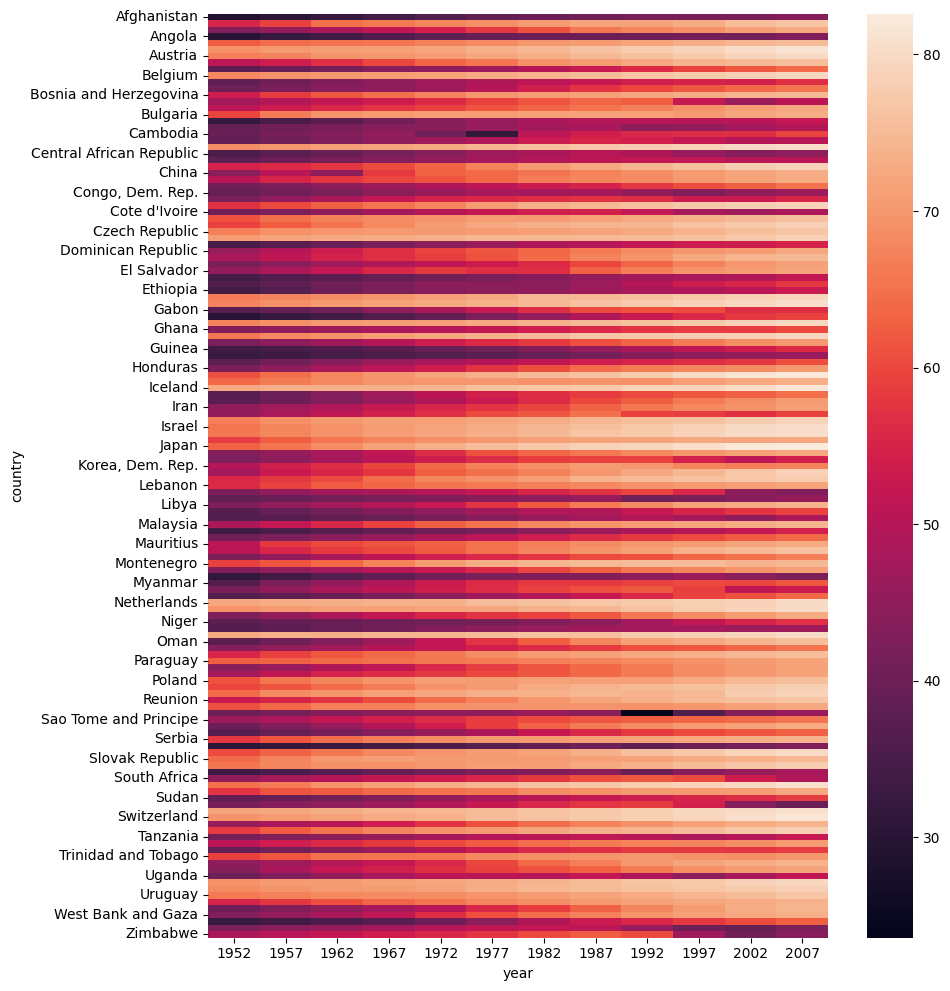

In [39]:
# heatmap only has an axes level function
plt.figure(figsize=(10,12))
sns.heatmap(temp_df)


In [40]:
# annot parameter - to see the value as well

temp_eu = gap[gap['continent'] == 'Europe'].pivot(index='country',columns='year',values='lifeExp')
temp_eu.head()

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
country,,,,,,,,,,,,
Albania,55.23,59.28,64.82,66.22,67.69,68.93,70.42,72.00,71.581,72.950,75.651,76.423
Austria,66.80,67.48,69.54,70.14,70.63,72.17,73.18,74.94,76.040,77.510,78.980,79.829
Belgium,68.00,69.24,70.25,70.94,71.44,72.80,73.93,75.35,76.460,77.530,78.320,79.441
Bosnia and Herzegovina,53.82,58.45,61.93,64.79,67.45,69.86,70.69,71.14,72.178,73.244,74.090,74.852
Bulgaria,59.60,66.61,69.51,70.42,70.90,70.81,71.08,71.34,71.190,70.320,72.140,73.005


<Axes: xlabel='year', ylabel='country'>

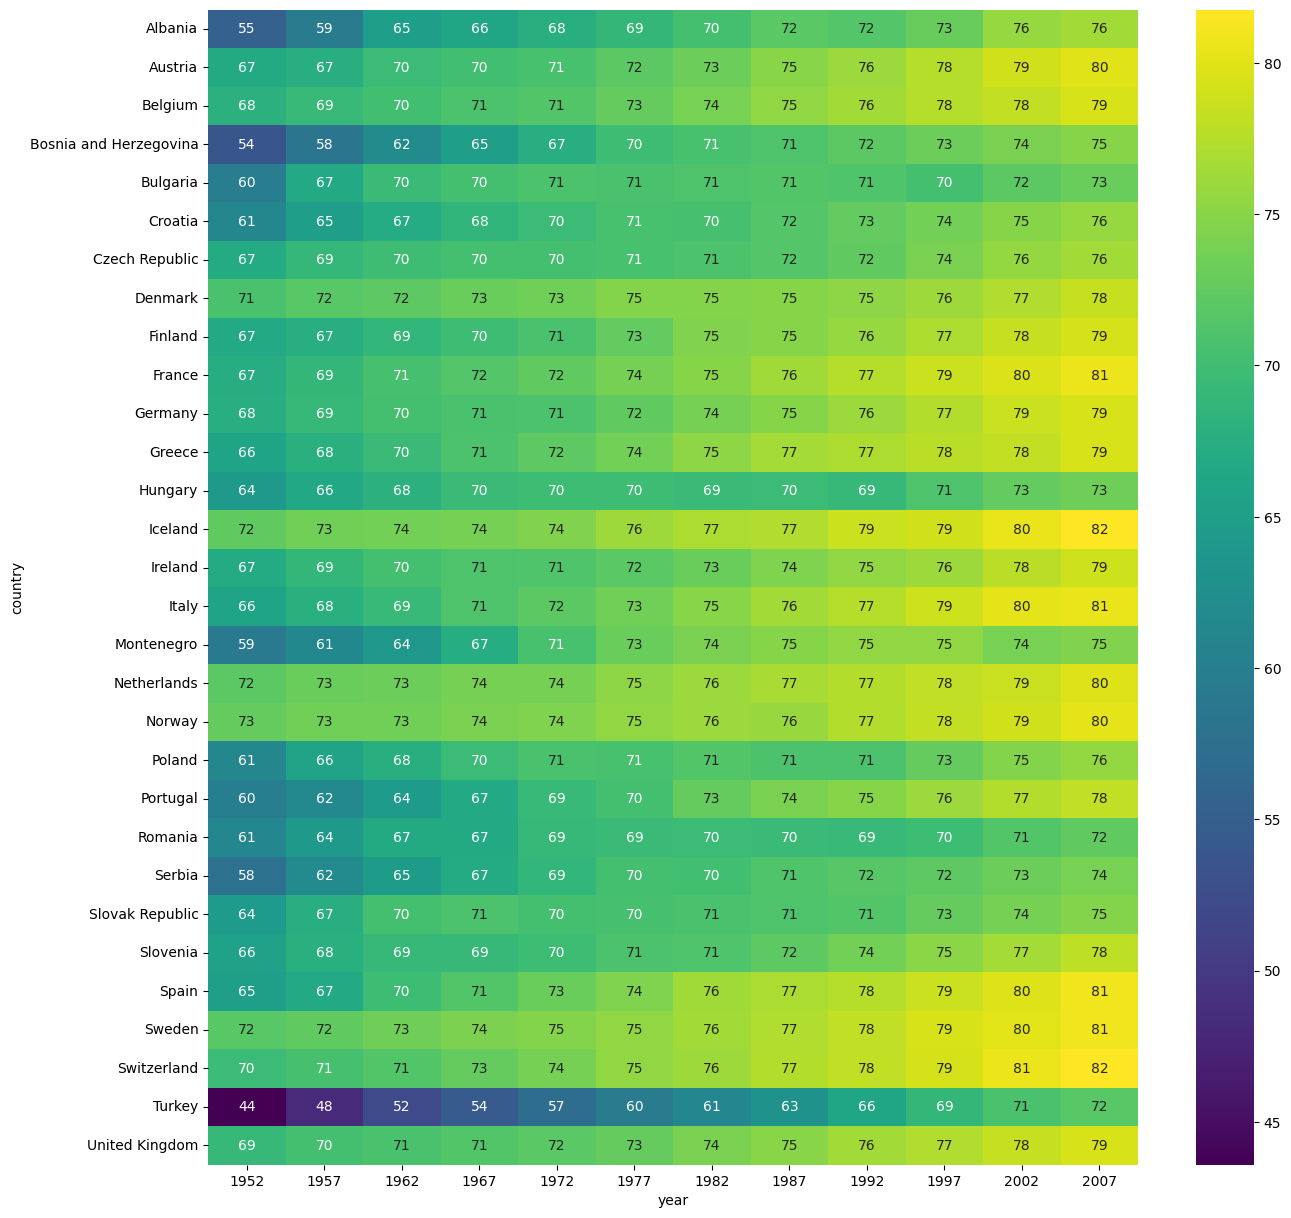

In [41]:
plt.figure(figsize=(15,15)) # always change the size before generating the graph


sns.heatmap(temp_eu,annot=True,cmap='viridis')

### Clustermap

- Similar to heatmap, but is plots a matrix dataset as a hierarchically-clustered heatmap.

- This function requires scipy to be available.

In [42]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


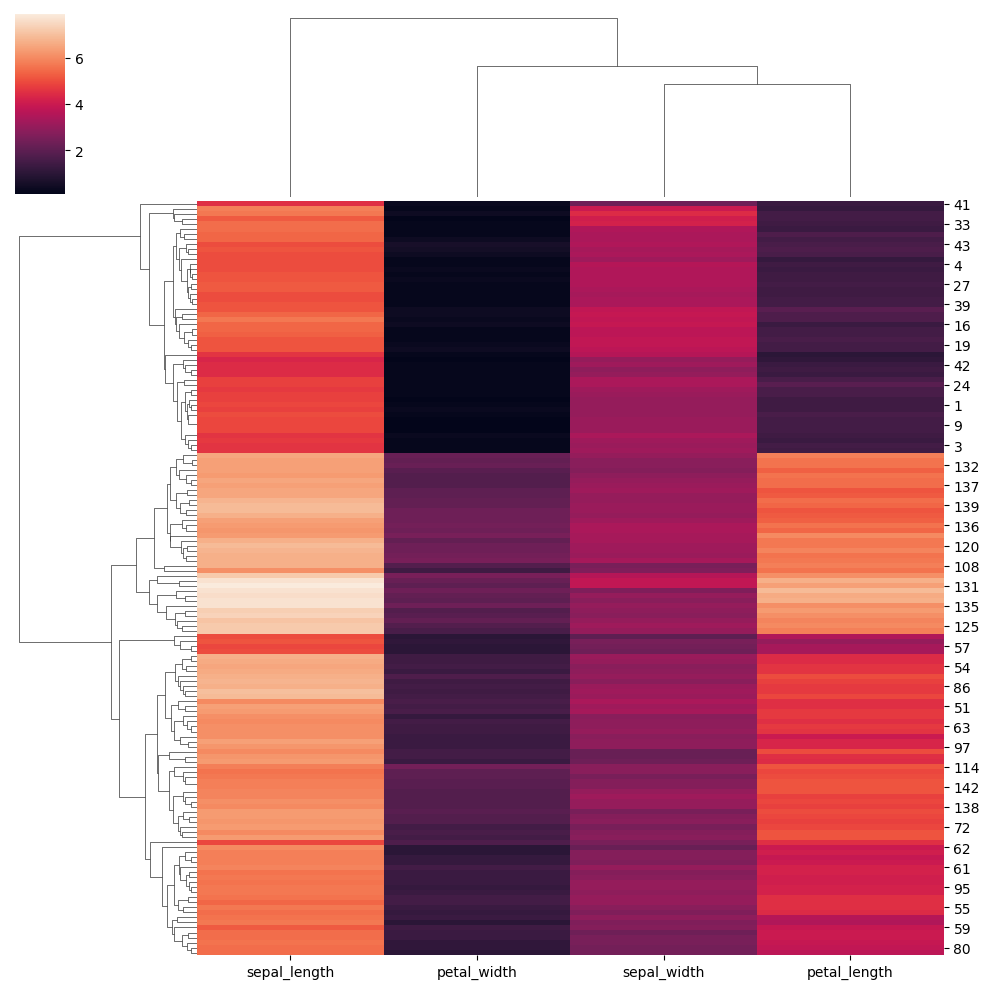

In [43]:
sns.clustermap(iris.iloc[:,[0,1,2,3]])

## 5. Regression Plot

- regplot
- lmplot

In the simplest invocation, both functions draw a scatterplot of two variables, x and y, and then fit the regression model y ~ x and plot the resulting regression line and a 95% condfidence interval for that regression.

The regplot() and lmplot() functions are closely related, but the former is an axes-level function while the latter is a figure-level function that combines regplot() and FacetGrid .


<Axes: xlabel='total_bill', ylabel='tip'>

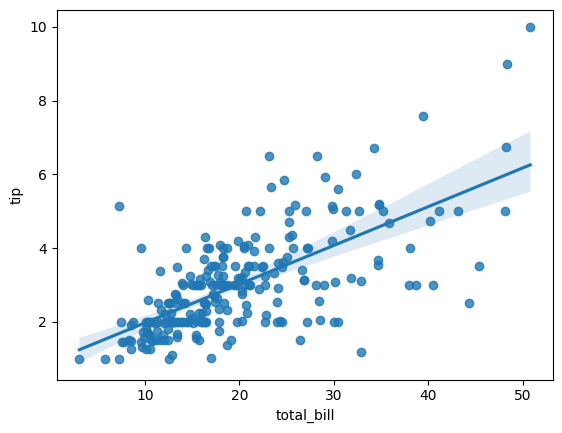

In [44]:
sns.regplot(data = tips, x='total_bill',y='tip')

#hue doesn't works in regplot.

# That solid line in the middle shows the regression, 
# and that shadow part gives the scope of error

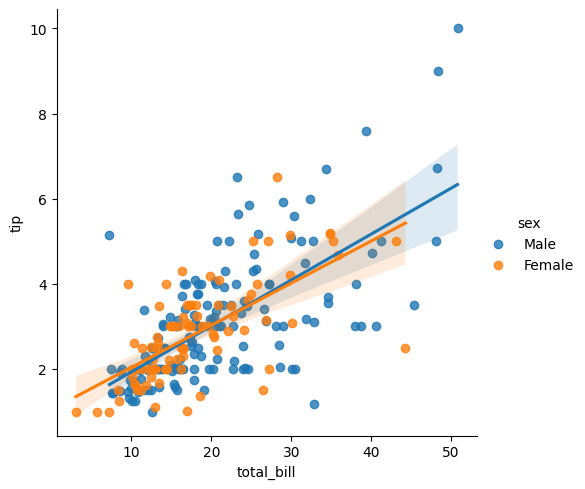

In [45]:
sns.lmplot(data=tips,x='total_bill',y='tip',hue='sex')

#### residplot


<Axes: xlabel='total_bill', ylabel='tip'>

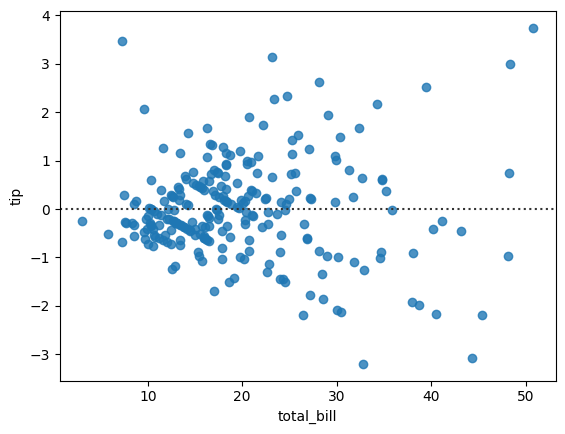

In [46]:
sns.residplot(data=tips, x='total_bill',y='tip')

## Multi-grid-plots

#### A second way to plot Facet Plots -> FacetGrid

So far 4 figure level functions that have facet plots -> relplot, displot, catplot, lnplot.

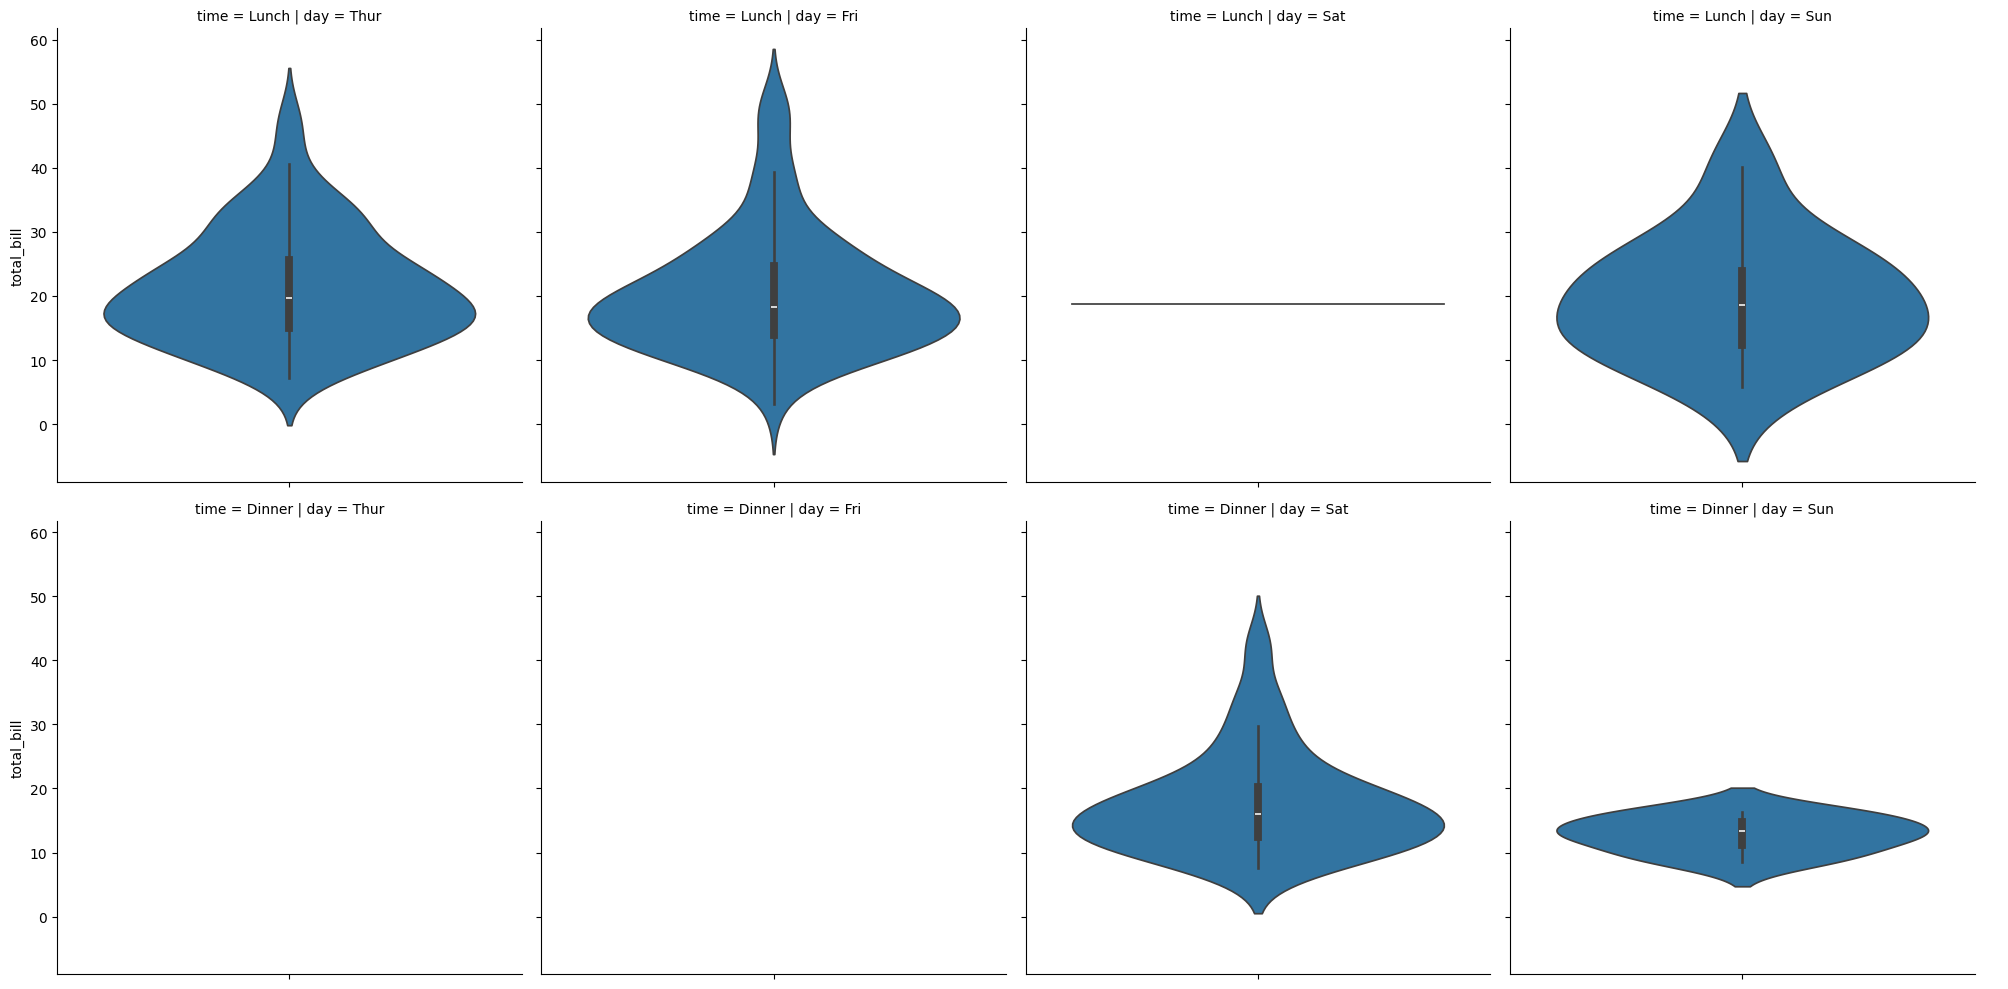

In [47]:
sns.catplot(data=tips, y='total_bill',kind='violin',col='day',row='time')

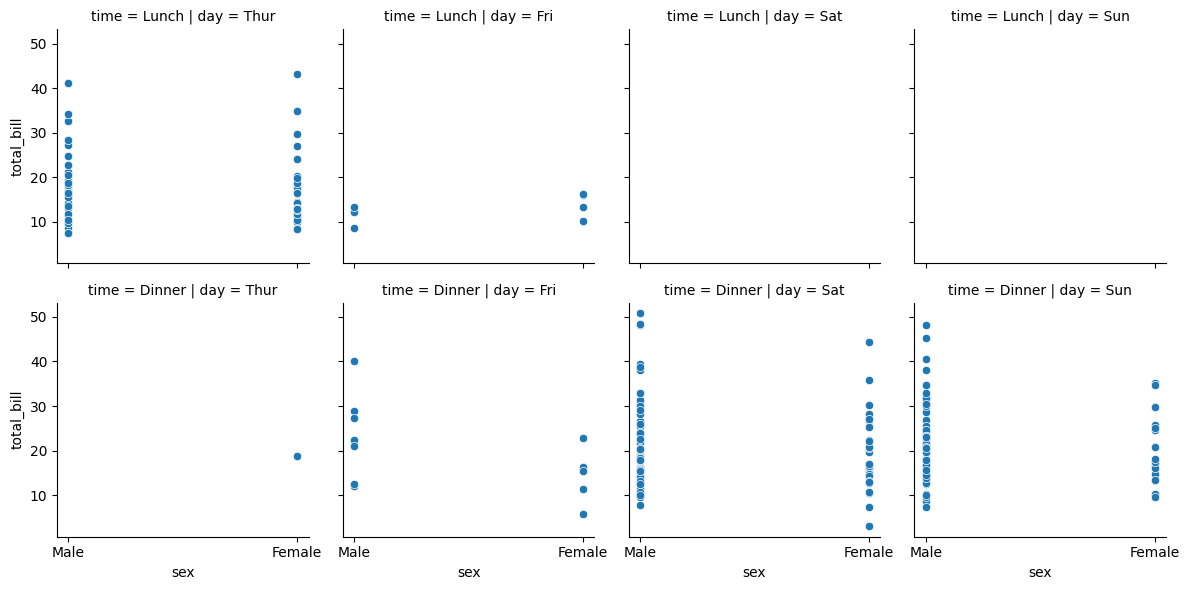

In [48]:
# Now let's make facet columns by using facetgrid.

g = sns.FacetGrid(data=tips,col='day',row='time') # this give a facet object.
g.map(sns.scatterplot,'sex','total_bill')
print(g)

#### Plotting Pairwise Relationship(PairGrid vs Pairplot)

In [51]:
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


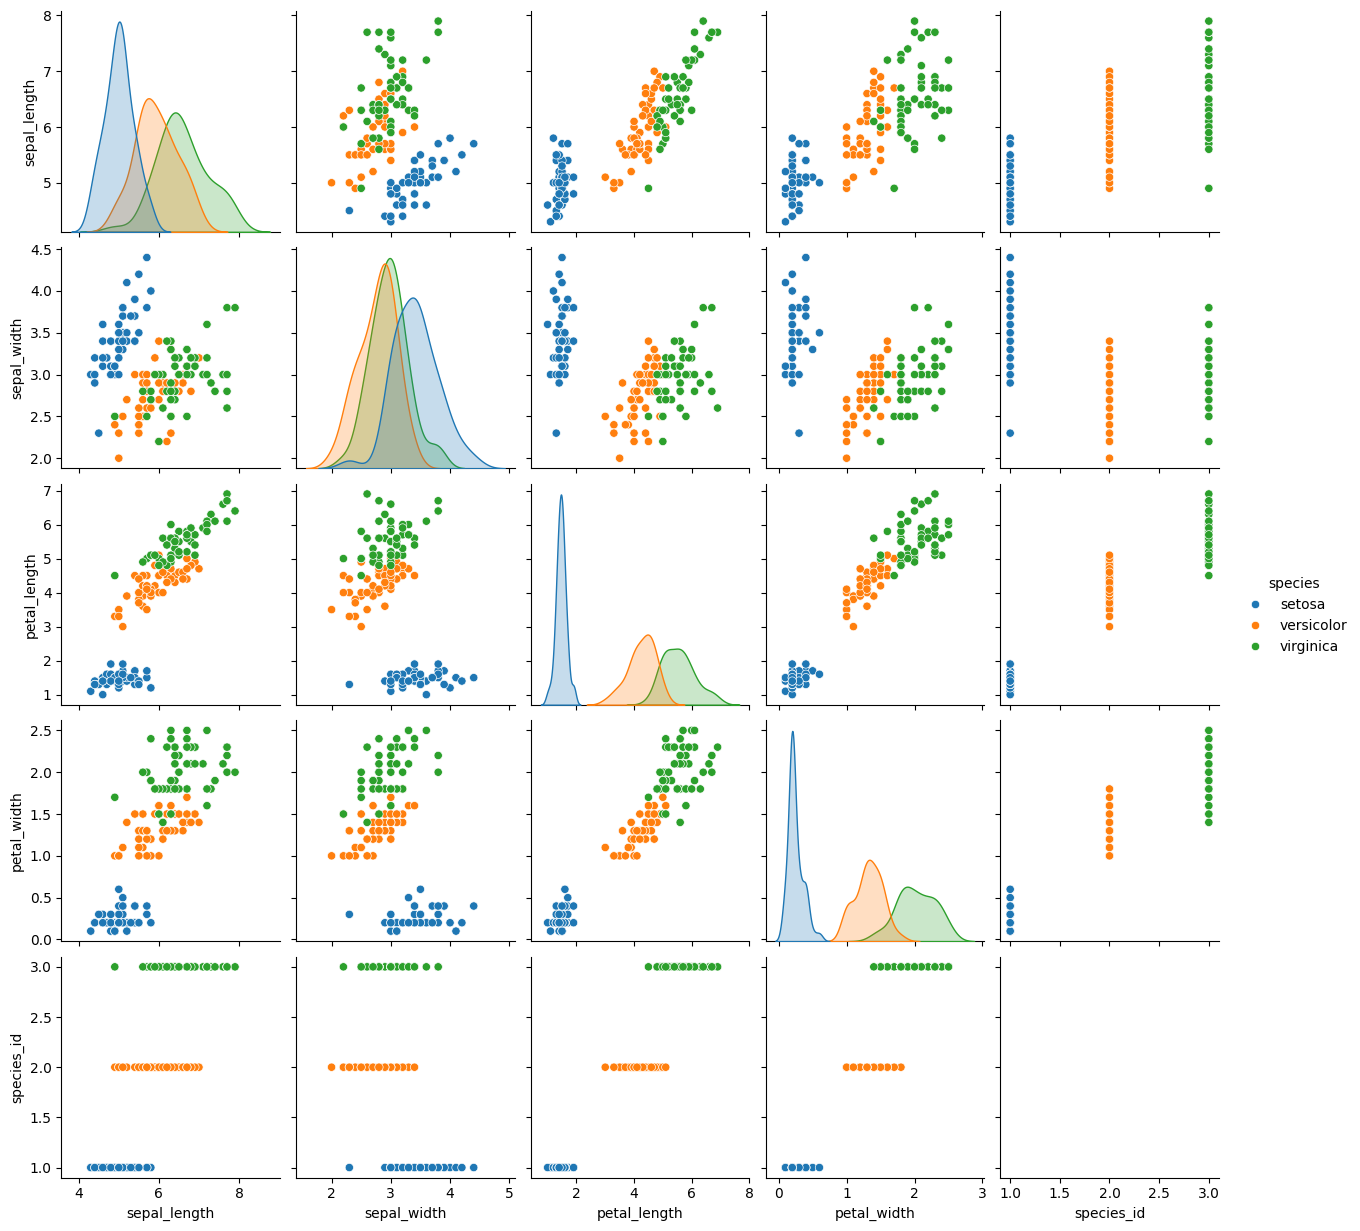

In [57]:
sns.pairplot(iris,hue='species')

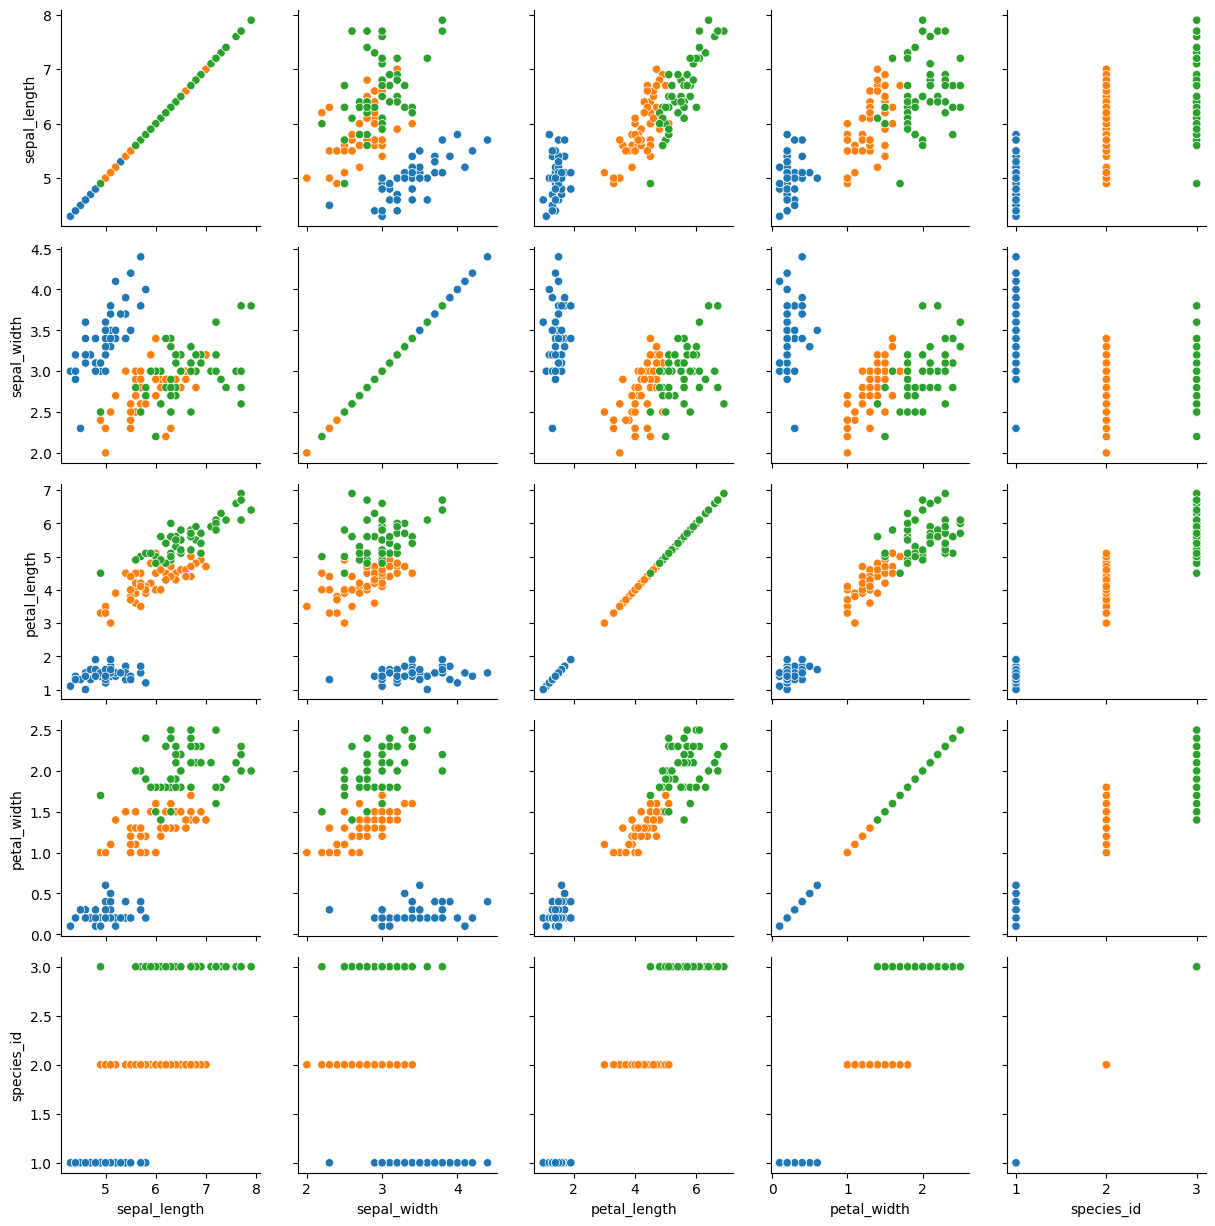

In [63]:
# pair grid
g = sns.PairGrid(data=iris,hue='species')
g.map(sns.scatterplot)

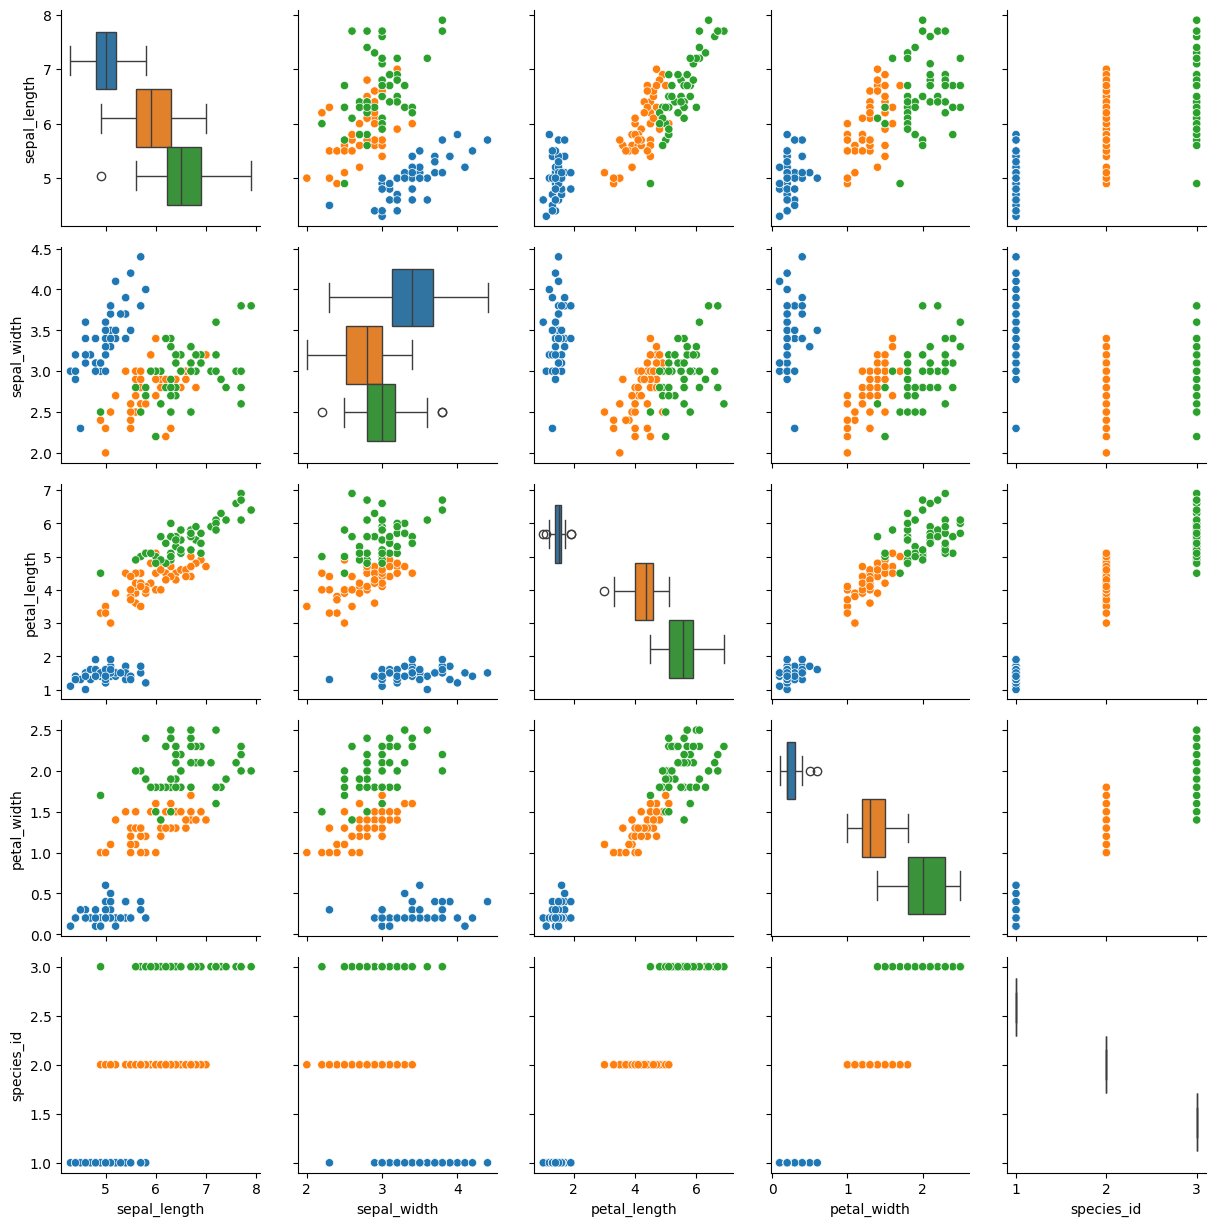

In [72]:
g = sns.PairGrid(data=iris,hue='species')
g.map_diag(sns.boxplot) # on the diagonal we have histogram
g.map_offdiag(sns.scatterplot) # except the diagonal we have scatterplot

#we can customize this as the requirement.

/Users/utkarshchouhan/Desktop/Python-Libraries/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:1513: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(x=vector, **plot_kwargs)


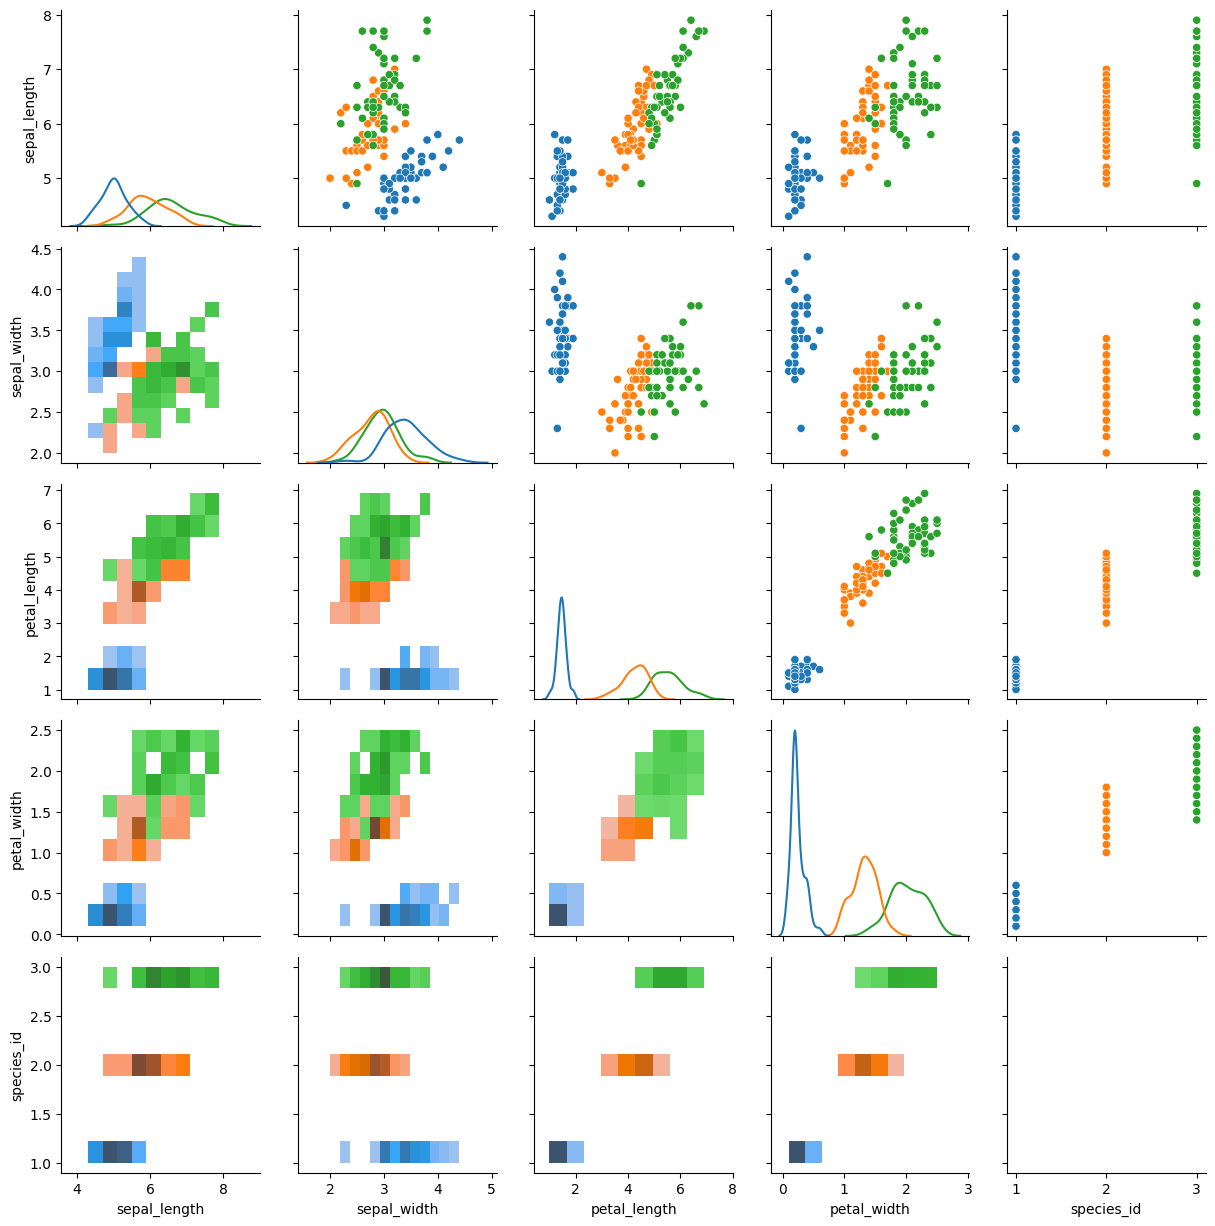

In [82]:
# We can also change the graphs above and below the diagonal

g = sns.PairGrid(data=iris,hue='species')
g.map_diag(sns.kdeplot) # on the diagonal we have kdeplot
g.map_upper(sns.scatterplot) # above the diagonal we have scatterplot
g.map_lower(sns.histplot) # below the diagonal we have histogram

#we can customize this as the requirement.

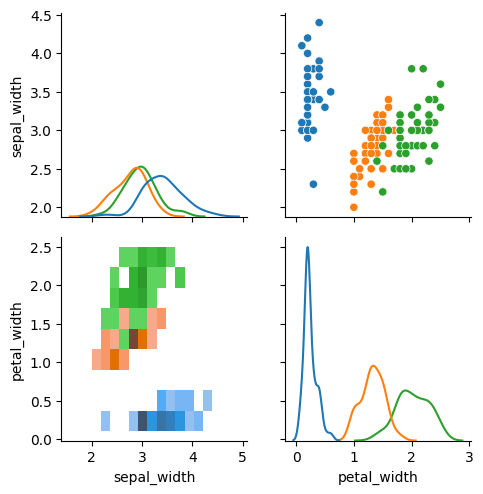

In [112]:
# We can limit the columns we wanna work with...

g = sns.PairGrid(data=iris,hue='species',vars=['sepal_width','petal_width'])
g.map_diag(sns.kdeplot) # on the diagonal we have kdeplot
g.map_upper(sns.scatterplot) # above the diagonal we have scatterplot
g.map_lower(sns.histplot) # below the diagonal we have histogram

#we can customize this as the requirement.

#### Joinplot and JointGrid

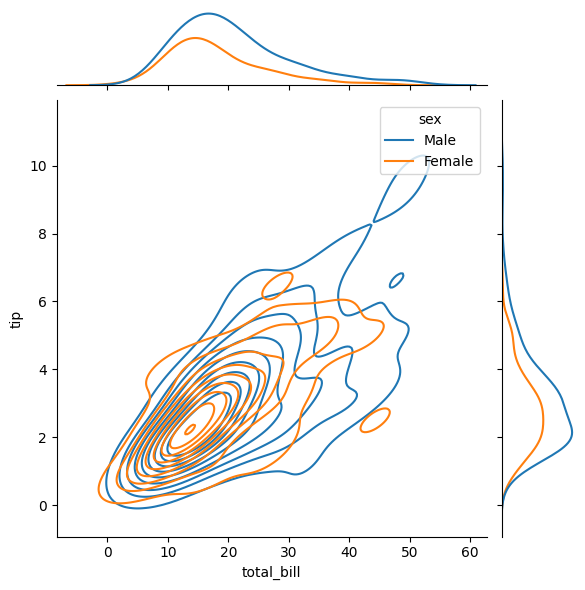

In [113]:
sns.jointplot(data=tips,x='total_bill',y='tip',hue='sex',kind='kde')
# default. kind='scatter', others = hex, scatter, hist, kde, reg, resid

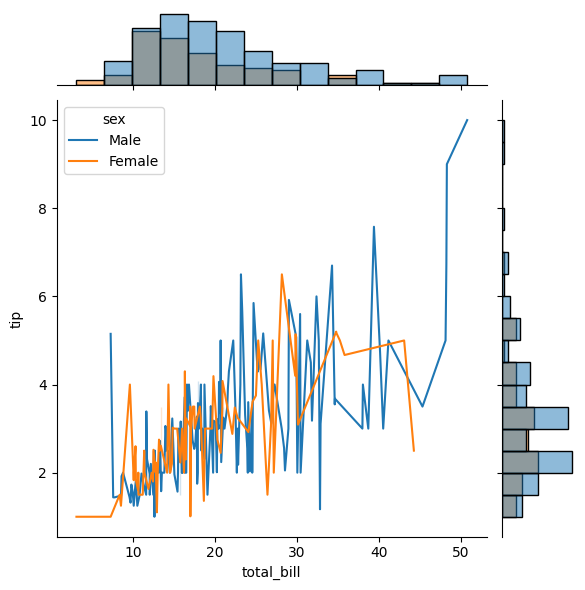

In [114]:
# plotting using joint grid

g = sns.JointGrid(data=tips, x= 'total_bill', y='tip',hue='sex')

# g.plot(sns.scatterplot,sns.histplot)
# g.plot(sns.histplot,sns.boxplot)
g.plot(sns.lineplot,sns.histplot)

#with JoinGrid we can choose a graph of our choice.

### Utility Functions

In [115]:
# get inbuilt dataset names in seaborn

sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [117]:
# loading the dataset

sns.load_dataset('planets')

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008
